In [1]:
import os
import numpy as np 
import pandas as pd 

# Machine Learning model specific
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix,classification_report,ConfusionMatrixDisplay

# Ploting routine
from matplotlib import pyplot as plt

GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
root_path = "/kaggle/input/datasets/akashkumbhakar"
folder_name = "blues-10000-csv"
file_name = "blues-10000.csv"


import warnings
warnings.filterwarnings("ignore")
print("✅")

✅


In [2]:
dfs = {}
for g in GENRES:
    folder_name = f"{g}-10000-csv"
    file_name = f"{g}-10000.csv"
    path =  os.path.join(root_path,folder_name,file_name)
    dfs[g] = pd.read_csv(path)
    dfs[g].rename(columns={"Unnamed: 0" : "label"},inplace=True)
    dfs[g]["label"] = g
print("✅ Dataframe loaded successfully.")

✅ Dataframe loaded successfully.


In [3]:
train_data = pd.concat(list(dfs.values()))

In [4]:
train_data.fillna(1,inplace=True)
train_data.isna().sum()

label             0
centroid_mean     0
centroid_var      0
bandwidth_mean    0
bandwidth_var     0
rolloff_mean      0
rolloff_var       0
rms               0
zcr               0
mfcc_mean1        0
mfcc_mean2        0
mfcc_mean3        0
mfcc_mean4        0
mfcc_mean5        0
mfcc_mean6        0
mfcc_mean7        0
mfcc_mean8        0
mfcc_mean9        0
mfcc_mean10       0
mfcc_mean11       0
mfcc_mean12       0
mfcc_mean13       0
mfcc_mean14       0
mfcc_mean15       0
mfcc_mean16       0
mfcc_mean17       0
mfcc_mean18       0
mfcc_mean19       0
mfcc_mean20       0
mfcc_var1         0
mfcc_var2         0
mfcc_var3         0
mfcc_var4         0
mfcc_var5         0
mfcc_var6         0
mfcc_var7         0
mfcc_var8         0
mfcc_var9         0
mfcc_var10        0
mfcc_var11        0
mfcc_var12        0
mfcc_var13        0
mfcc_var14        0
mfcc_var15        0
mfcc_var16        0
mfcc_var17        0
mfcc_var18        0
mfcc_var19        0
mfcc_var20        0
dtype: int64

In [5]:
# Spliting to train and test 
cols = list(train_data.columns)
x_t,x_v,y_t,y_v = train_test_split(train_data[cols[1:]],train_data['label'],test_size=0.2, stratify=train_data['label'],random_state=0)
print(x_t.shape,x_v.shape,y_t.shape,y_v.shape)

(80000, 48) (20000, 48) (80000,) (20000,)


# ML Models

In [6]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
x_tt = scaler.fit_transform(x_t)
x_vt = scaler.transform(x_v)


lr_model = LogisticRegression()
lr_model.fit(x_tt,y_t)
print(f"✅ {lr_model}")

✅ LogisticRegression()


Macro F1 :  0.7014443276150597
              precision    recall  f1-score   support

       blues       0.67      0.71      0.69      2000
   classical       0.88      0.89      0.88      2000
     country       0.60      0.56      0.58      2000
       disco       0.61      0.60      0.60      2000
      hiphop       0.64      0.64      0.64      2000
        jazz       0.78      0.76      0.77      2000
       metal       0.86      0.91      0.88      2000
         pop       0.81      0.85      0.83      2000
      reggae       0.60      0.58      0.59      2000
        rock       0.55      0.53      0.54      2000

    accuracy                           0.70     20000
   macro avg       0.70      0.70      0.70     20000
weighted avg       0.70      0.70      0.70     20000



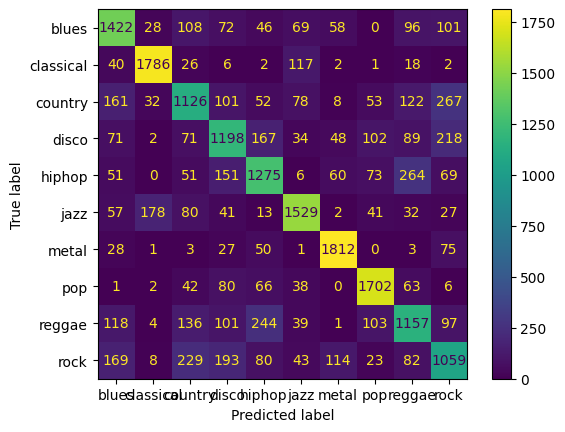

In [7]:
# Predict lr-model
y_p = lr_model.predict(x_vt)
macro_f1 = f1_score(y_v,y_p,average='macro')
print("Macro F1 : ", macro_f1)

cm = confusion_matrix(y_v,y_p,labels=lr_model.classes_)
cr = classification_report(y_v,y_p,labels=lr_model.classes_)
print(cr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lr_model.classes_)
disp.plot()
plt.show()

In [8]:
# Nearest Neighbour
from sklearn.neighbors import KNeighborsClassifier#

model = KNeighborsClassifier()
model.fit(x_tt, y_t)

print(f"✅ {model}")

✅ KNeighborsClassifier()


Macro F1 :  0.8478482473144299
              precision    recall  f1-score   support

       blues       0.89      0.87      0.88      2000
   classical       0.96      0.98      0.97      2000
     country       0.79      0.82      0.80      2000
       disco       0.72      0.80      0.76      2000
      hiphop       0.74      0.86      0.80      2000
        jazz       0.98      0.90      0.94      2000
       metal       0.97      0.88      0.92      2000
         pop       0.86      0.94      0.90      2000
      reggae       0.77      0.82      0.79      2000
        rock       0.86      0.62      0.73      2000

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



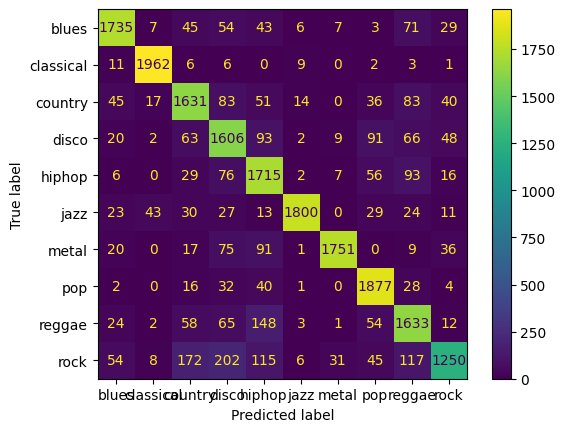

In [9]:
# Predict svc-model
y_p = model.predict(x_vt)
macro_f1 = f1_score(y_v,y_p,average='macro')
print("Macro F1 : ", macro_f1)

cm = confusion_matrix(y_v,y_p,labels=model.classes_)
cr = classification_report(y_v,y_p,labels=model.classes_)
print(cr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()

In [10]:
# Support vector machine
from sklearn.svm import SVC
model = SVC()
model.fit(x_tt, y_t)

print(f"✅ {model}")

✅ SVC()


Macro F1 :  0.8740776173883862
              precision    recall  f1-score   support

       blues       0.88      0.92      0.90      2000
   classical       0.97      0.98      0.98      2000
     country       0.83      0.81      0.82      2000
       disco       0.81      0.82      0.82      2000
      hiphop       0.83      0.83      0.83      2000
        jazz       0.95      0.94      0.94      2000
       metal       0.94      0.95      0.95      2000
         pop       0.91      0.93      0.92      2000
      reggae       0.82      0.83      0.82      2000
        rock       0.81      0.75      0.78      2000

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000



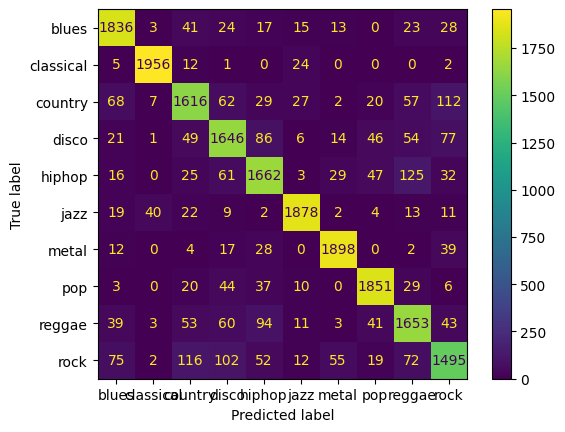

In [11]:
# Predict svc-model
y_p = model.predict(x_vt)
macro_f1 = f1_score(y_v,y_p,average='macro')
print("Macro F1 : ", macro_f1)

cm = confusion_matrix(y_v,y_p,labels=model.classes_)
cr = classification_report(y_v,y_p,labels=model.classes_)
print(cr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()

# Test features  and submission

In [12]:
path_to_test_set = "/kaggle/input/datasets/akashkumbhakar/test-features-3020/test_music_features.csv"
test_data = pd.read_csv(path_to_test_set)
x_test = test_data[list(test_data.columns)[1:]]


In [13]:
x_test.head(5)

,centroid_mean,centroid_var,bandwidth_mean,bandwidth_var,rolloff_mean,rolloff_var,rms,zcr,mfcc_mean1,mfcc_mean2,...,mfcc_var11,mfcc_var12,mfcc_var13,mfcc_var14,mfcc_var15,mfcc_var16,mfcc_var17,mfcc_var18,mfcc_var19,mfcc_var20
0,3249.631776,7.927954e+05,3149.349375,145402.393350,7295.184425,2.326239e+06,0.133146,0.138722,-94.91693,62.049244,...,87.244194,71.04333,60.455048,60.407627,65.334080,75.542560,60.892994,46.62774,63.011246,60.031520
1,1840.967564,1.044553e+06,1895.230540,817757.909079,3827.767231,4.663699e+06,0.116923,0.094752,-214.88423,68.716630,...,112.215640,165.49942,106.358340,95.619990,86.093550,88.134800,76.771710,97.62339,56.687244,94.941230
2,2443.036869,4.458258e+05,2394.855726,171522.444957,5143.587284,2.002713e+06,0.127057,0.114988,-133.75146,79.453390,...,208.821300,193.73422,118.991250,69.654640,107.589810,93.372360,99.453150,132.00275,135.756970,79.370186
3,2499.126101,2.752596e+05,2365.091629,127694.288836,5187.037209,1.080896e+06,0.128685,0.119345,-96.33206,79.249916,...,113.939060,124.01004,157.940570,99.515526,82.425200,83.090195,61.509810,61.60231,59.688145,71.114440
4,1888.231842,8.785095e+05,1960.512659,329874.803720,3812.934072,3.566916e+06,0.127429,0.087607,-161.51538,106.821320,...,122.171974,111.39160,69.658550,82.857475,88.024254,71.040560,61.950516,90.34207,68.646280,57.126015


In [14]:
sample_dir = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv"
sample_sub = pd.read_csv(sample_dir)

In [15]:
sample_sub.head()

,id,genre
0,1,jazz
1,2,blues
2,3,classical
3,4,pop
4,5,disco


In [16]:
x_test_transform = scaler.transform(x_test)
y_pred = model.predict(x_test_transform)

In [17]:
sample_sub['genre'] = y_pred

In [18]:
sample_sub.to_csv('submission.csv')
print("✅ Submission successfully completed.")

✅ Submission successfully completed.
